# Финальный проект

Для решения поставленной задачи будет произведен простой пайплайн:
1. Считывание данных
2. Деление данных на train/test - 4000 точек как входные параметры и 1000 точек как предсказание
3. Применение фильтра Калмана для приведения сигнала к менее зашумленному виду
4. Обучение модели
5. Валидация результатов обучения

# Подготовка данных

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.lib.stride_tricks import sliding_window_view

from tslearn.neural_network import TimeSeriesMLPRegressor

plt.style.use("seaborn-v0_8")

In [2]:
def estimate_kalman_params(noisy: np.ndarray, clean: np.ndarray, eps: float = 1e-8) -> dict:
    measurement_noise = noisy - clean
    process_increments = np.diff(clean, axis=1)
    q = float(np.var(process_increments) + eps)
    r = float(np.var(measurement_noise) + eps)
    x0 = float(np.mean(clean[:, 0]))
    p0 = float(np.var(clean[:, 0]) + r)
    return {'q': q, 'r': r, 'x0': x0, 'p0': p0}


def kalman_filter_1d(signal: np.ndarray, q: float, r: float, x0: float | None = None, p0: float | None = None) -> np.ndarray:
    x_hat = float(signal[0] if x0 is None else x0)
    p = float(max(r, 1e-8) if p0 is None else p0)
    filtered = np.empty_like(signal, dtype=float)

    for i, y in enumerate(signal):
        p = p + q
        k = p / (p + r)
        x_hat = x_hat + k * (y - x_hat)
        p = (1.0 - k) * p
        filtered[i] = x_hat

    return filtered


def apply_kalman_filter(noisy: np.ndarray, params: dict) -> np.ndarray:
    return np.vstack([
        kalman_filter_1d(signal, params['q'], params['r'], params['x0'], params['p0'])
        for signal in noisy
    ])


In [3]:
train_noisy = pd.read_csv('train.csv', header=None).to_numpy(dtype=float)
train_clean = pd.read_csv('etalon_for_train.csv', header=None).to_numpy(dtype=float)
test_noisy = pd.read_csv('test.csv', header=None).to_numpy(dtype=float)
test_clean = pd.read_csv('etalon_for_test.csv', header=None).to_numpy(dtype=float)

print('train_noisy:', train_noisy.shape)
print('train_clean:', train_clean.shape)
print('test_noisy :', test_noisy.shape)
print('test_clean :', test_clean.shape)



train_noisy: (1000, 5000)
train_clean: (1000, 5000)
test_noisy : (500, 5000)
test_clean : (500, 5000)


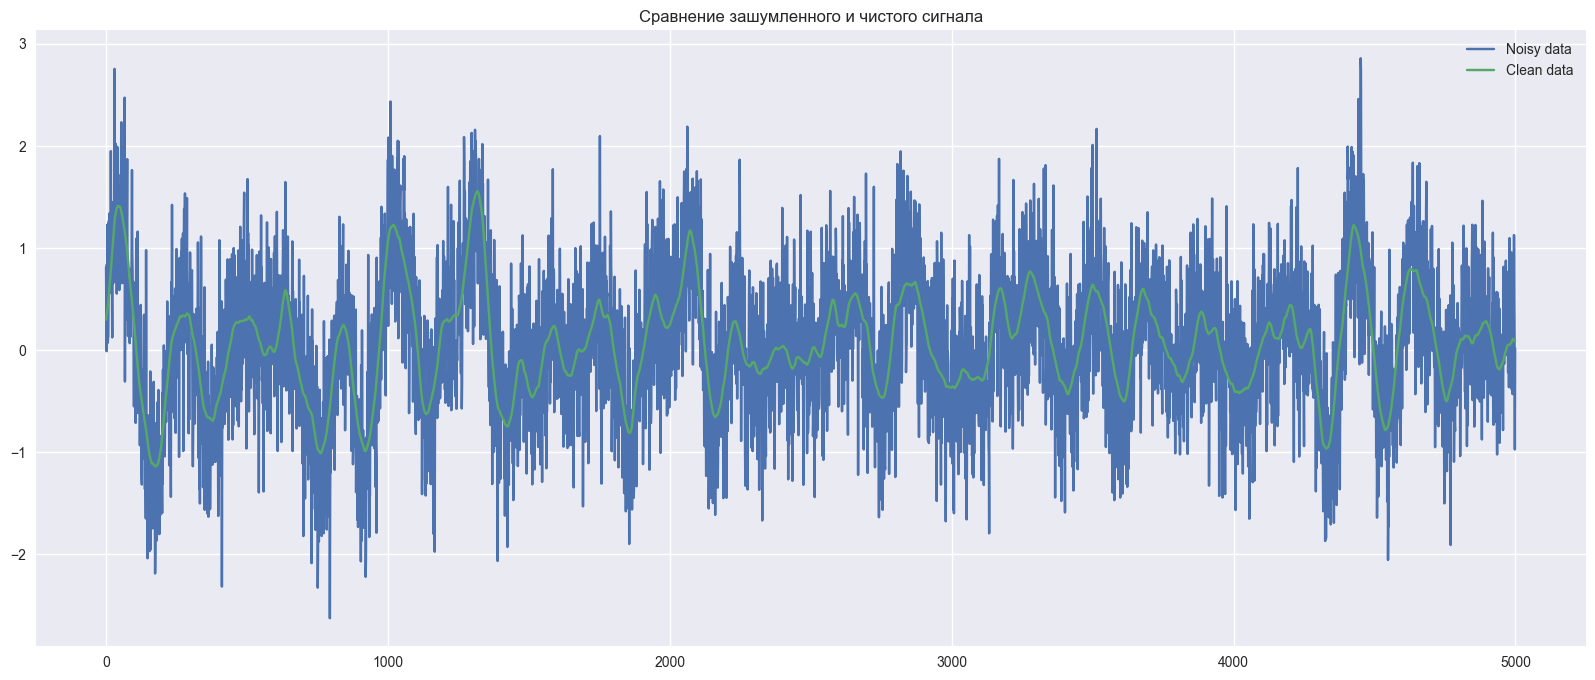

In [4]:
plt.figure(figsize=(20,8))
plt.plot(train_noisy[0], label = "Noisy data")
plt.plot(train_clean[0], label = "Clean data")
plt.legend()
plt.title(f"Сравнение зашумленного и чистого сигнала")
plt.show()

# Разделение данных

In [52]:
split = 4000
x_train_noisy, x_val_noisy = train_noisy[:, :split], train_noisy[:, split:]
x_train_clean, x_val_clean = train_clean[:, :split], train_clean[:, split:]

x_test_noisy, x_test_val_noisy = test_noisy[:, :split], test_noisy[:, split:]
x_test_clean, x_test_val_clean = test_clean[:, :split], test_clean[:, split:]

# Фильтрация шума фильтром Калмана

In [ ]:
kalman_params = estimate_kalman_params(x_train_noisy[:, :split], x_train_clean[:, :split])

In [74]:
def mean_forecast_error(L, true, preds):
    print(true.shape, preds.shape)
    return (true + preds).sum(axis=1, keepdims=True) / L

def RMS(L, true, preds):
    delta = mean_forecast_error(L, true.T, preds.T)
    result = []
    for i in range(len(true)):
        subdelta = np.sqrt(np.sum(np.square(true[i]-preds[i]-delta[i]))/(L-1))
        result.append(subdelta)
    return result
        

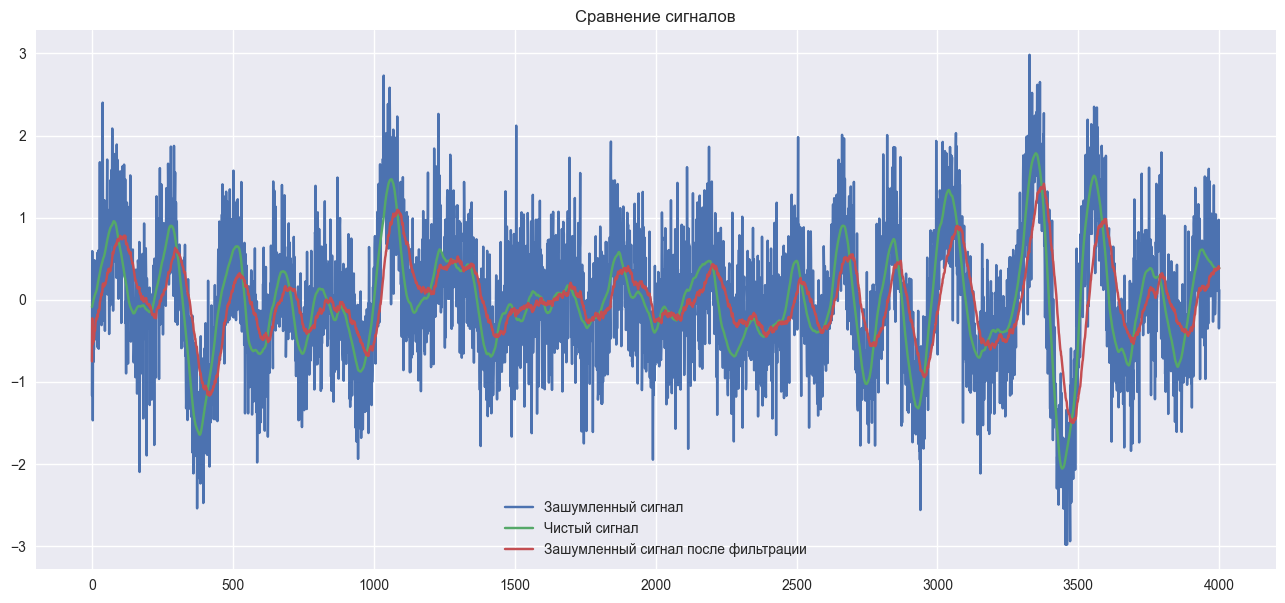

In [81]:
idx = 10
plt.figure(figsize=(16,7))
x_1 = np.linspace(0,4000,4000)
plt.plot(x_1,x_train_noisy[idx], label = "Зашумленный сигнал")
plt.plot(x_1,x_train_clean[idx], label = "Чистый сигнал")
plt.plot(x_1,apply_kalman_filter(x_train_noisy, kalman_params)[idx], label = "Зашумленный сигнал после фильтрации")
plt.title('Сравнение сигналов')
plt.legend()

# Обучение модели

In [9]:
from sklearn.metrics import mean_squared_error

In [57]:
model = TimeSeriesMLPRegressor(activation='tanh', solver='adam', max_iter=500, verbose=True)
model.fit(apply_kalman_filter(x_train_noisy, kalman_params), x_val_clean)


Iteration 1, loss = 0.14868550
Iteration 2, loss = 0.14044132
Iteration 3, loss = 0.13660390
Iteration 4, loss = 0.13276723
Iteration 5, loss = 0.12978885
Iteration 6, loss = 0.12752654
Iteration 7, loss = 0.12627848
Iteration 8, loss = 0.12498322
Iteration 9, loss = 0.12392207
Iteration 10, loss = 0.12291837
Iteration 11, loss = 0.12251277
Iteration 12, loss = 0.12187862
Iteration 13, loss = 0.12093742
Iteration 14, loss = 0.12009012
Iteration 15, loss = 0.11957238
Iteration 16, loss = 0.11910227
Iteration 17, loss = 0.11841472
Iteration 18, loss = 0.11766915
Iteration 19, loss = 0.11746527
Iteration 20, loss = 0.11657453
Iteration 21, loss = 0.11604217
Iteration 22, loss = 0.11526623
Iteration 23, loss = 0.11463669
Iteration 24, loss = 0.11355041
Iteration 25, loss = 0.11299635
Iteration 26, loss = 0.11148511
Iteration 27, loss = 0.11071994
Iteration 28, loss = 0.10916678
Iteration 29, loss = 0.10752766
Iteration 30, loss = 0.10593215
Iteration 31, loss = 0.10422197
Iteration 32, los

,loss,'squared_error'
,hidden_layer_sizes,"(100,)"
,activation,'tanh'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True


In [58]:
preds = model.predict(apply_kalman_filter(x_test_noisy, kalman_params))
mean_squared_error(preds, x_test_val_clean)

C:\Users\k_dys\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tslearn\utils\utils.py:129: UserWarning: 2-Dimensional data passed. Assuming these are 500 1-dimensional timeseries
  warnings.warn(


0.4957572440485609

In [62]:
mean_forecast_error(len(preds), preds.T, x_test_val_clean.T).shape

(1000, 500) (1000, 500)


(1000, 1)

In [63]:
len(RMS(len(preds), preds, x_test_val_clean))

(1000, 500) (1000, 500)


500

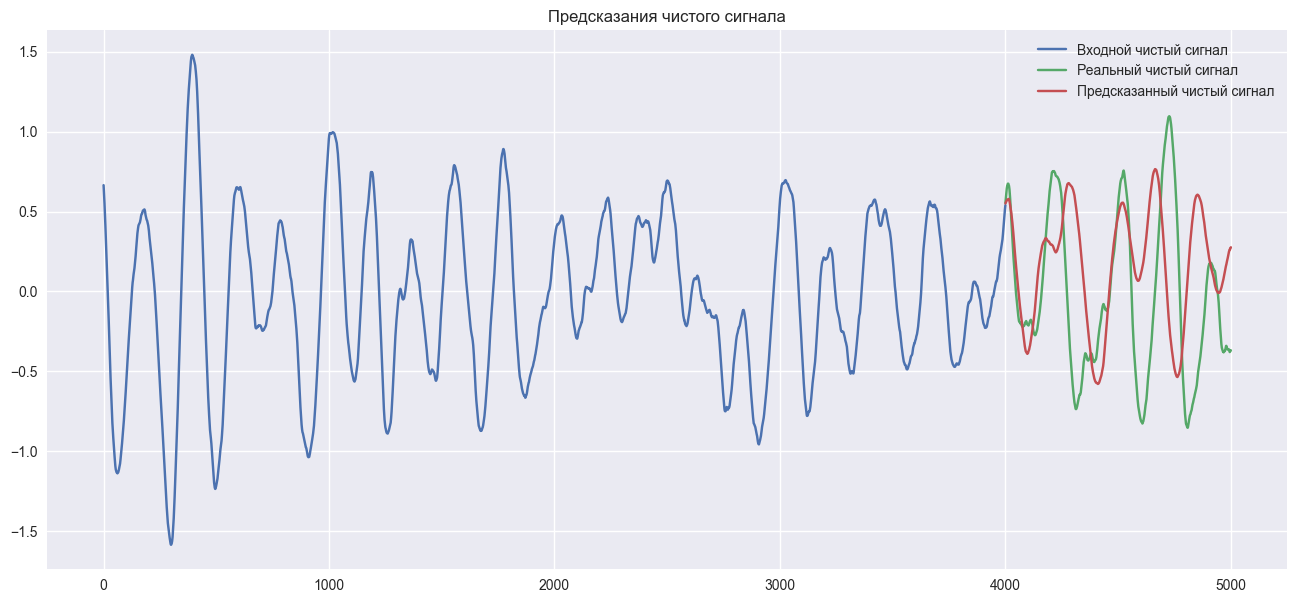

In [67]:
idx = 10
plt.figure(figsize=(16,7))
x_1 = np.linspace(0,4000,4000)
plt.plot(x_1,x_test_clean[idx], label = "Входной чистый сигнал")
x_2 = np.linspace(4000,5000,1000)
plt.plot(x_2,x_test_val_clean[idx], label = "Реальный чистый сигнал")
plt.plot(x_2,preds[idx], label = "Предсказанный чистый сигнал")
plt.title('Предсказания чистого сигнала')
plt.legend()

(1000, 500) (1000, 500)


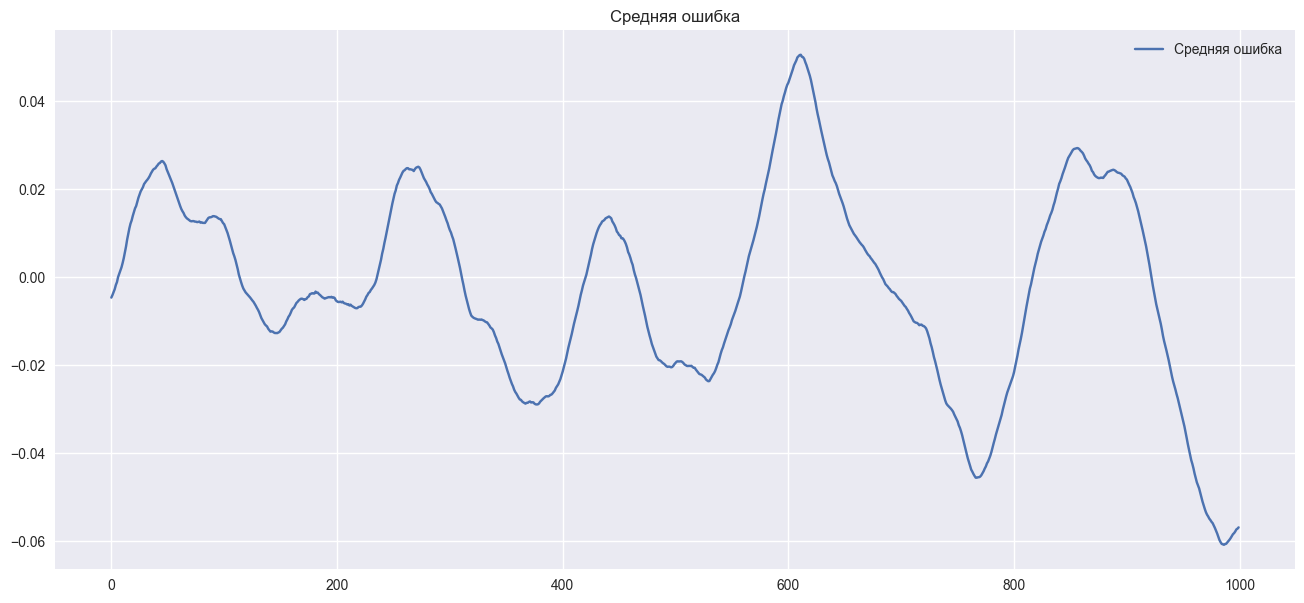

In [77]:
idx = 1
plt.figure(figsize=(16,7))
plt.plot(mean_forecast_error(len(preds), preds.T, x_test_val_clean.T), label = "Средняя ошибка")
plt.title('Средняя ошибка')
plt.legend()

(1000, 500) (1000, 500)


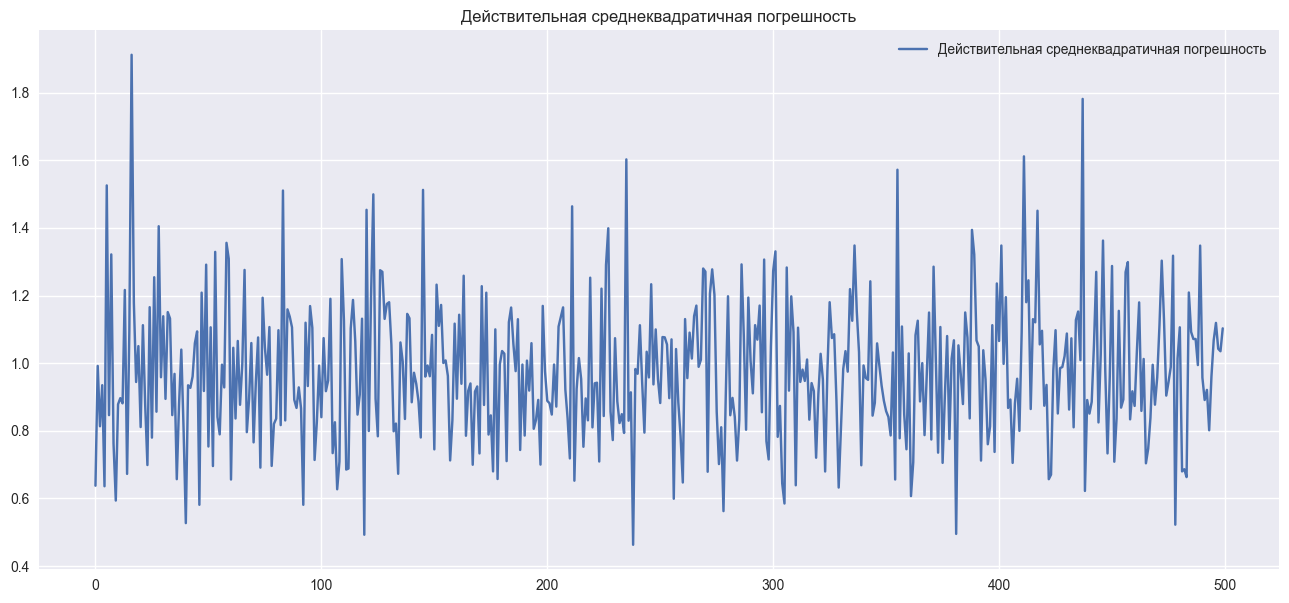

In [83]:
idx = 1
plt.figure(figsize=(16,7))
plt.plot(RMS(len(preds), preds, x_test_val_clean), label = "Действительная среднеквадратичная погрешность")
plt.title('Действительная среднеквадратичная погрешность')
plt.legend()
